#**Data Loading**

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Loading Dataset
dataset, dataset_info = tfds.load("malaria", with_info = True, split = "train", as_supervised = True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/malaria/incomplete.ETU6GV_1.0.0/malaria-train.tfrecord*...:   0%|         …

Dataset malaria downloaded and prepared to /root/tensorflow_datasets/malaria/1.0.0. Subsequent calls will reuse this data.


#**Preprocessing**

In [3]:
#Splits the data into train, validation and test sets
def split(dataset, train_size, val_size):
    dataset_size = len(dataset)
    train_dataset = dataset.take(int(dataset_size*train_size))
    val_test_dataset = dataset.skip(int(dataset_size*train_size))
    val_dataset = val_test_dataset.take(int(dataset_size*val_size))
    test_dataset = val_test_dataset.skip(int(dataset_size*val_size))
    return train_dataset, val_dataset, test_dataset

In [4]:
train_dataset, val_dataset, test_dataset = split(dataset, 0.8, 0.1)
print(train_dataset)
print(f"Train Dataset Length: {len(train_dataset)}")
print(val_dataset)
print(f"Validation Dataset Length: {len(val_dataset)}")
print(test_dataset)
print(f"Test Dataset Length: {len(test_dataset)}")

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
Train Dataset Length: 22046
<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
Validation Dataset Length: 2755
<_SkipDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>
Test Dataset Length: 2757


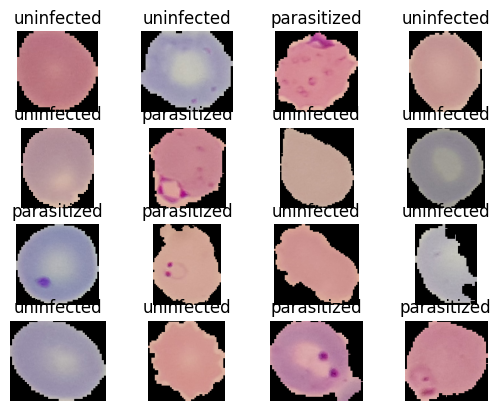

In [5]:
#Visualizing the data
import matplotlib.pyplot as plt

for i, (image, label) in enumerate(train_dataset.take(16)):
    plt.subplot(4, 4, i + 1)
    plt.imshow(image)
    plt.title(dataset_info.features["label"].int2str(label))
    plt.axis("off")

1
uninfected


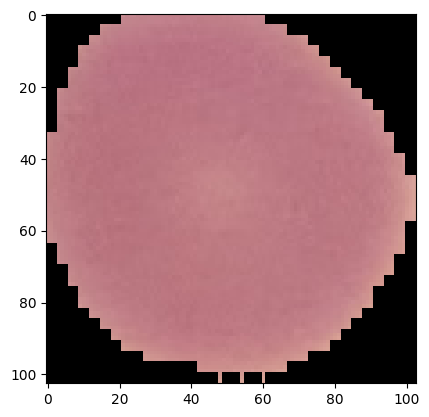

In [6]:
#class 1 corresponds to uninfected and class 0 corresponds to infected
image, label = next(train_dataset.take(1).as_numpy_iterator())
plt.imshow(image)
print(label)
print(dataset_info.features["label"].int2str(label))


In [7]:
#Resizing and Scaling the data to ensure consistency. The size of the image should be the multiple of the aspect ratio to avoid distortion.
resize_layer = tf.keras.layers.Resizing(256, 256)
rescale_layer = tf.keras.layers.Rescaling(1/255)

def resize_scale(image, label):
    image = resize_layer(image)
    image = rescale_layer(image)
    return image, label

train_dataset = train_dataset.map(resize_scale)
val_dataset = val_dataset.map(resize_scale)
test_dataset = test_dataset.map(resize_scale)

In [8]:
train_dataset

<_MapDataset element_spec=(TensorSpec(shape=(256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [9]:
#Shuffling, Batching and Prefetching
train_dataset = train_dataset.shuffle(buffer_size = 162).batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.shuffle(buffer_size = 162).batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

#**Model Architecture**

In [10]:
#This architecture is hyperparameter tuned on validation dataset.
from keras.layers import Normalization, Dense, Input, Conv2D, MaxPool2D, Flatten, BatchNormalization

model = tf.keras.Sequential([
    Input(shape = (256, 256, 3)),

    Conv2D(filters = 4, kernel_size = 3, strides = 1, padding = 'valid', activation = "relu", use_bias = False),
    BatchNormalization(),
    MaxPool2D(pool_size = 2, strides = 2),

    Conv2D(filters = 16, kernel_size = 3, strides = 1, padding = 'valid', activation = "relu", use_bias = False),
    BatchNormalization(),
    MaxPool2D(pool_size = 2, strides = 2),

    Conv2D(filters = 64, kernel_size = 3, strides = 1, padding = 'valid', activation = "relu", use_bias = False),
    BatchNormalization(),
    MaxPool2D(pool_size = 2, strides = 2),

    Conv2D(filters = 64, kernel_size = 3, strides = 1, padding = 'valid', activation = "relu", use_bias = False),
    BatchNormalization(),
    MaxPool2D(pool_size = 2, strides = 2),

    Conv2D(filters = 32, kernel_size = 3, strides = 1, padding = 'valid', activation = "relu", use_bias = False),
    BatchNormalization(),
    MaxPool2D(pool_size = 2, strides = 2),

    Flatten(),

    Dense(500, activation = "relu"),
    BatchNormalization(),

    Dense(250, activation = "relu"),
    BatchNormalization(),

    Dense(1, activation = "sigmoid")
])

**<p align="center">Feature Map Formulas</p>**

When padding = 'valid':

>>Feature Map Dimension = ((Input Dimension - Kernell Size)/Stride)) + 1

When padding = 'same':

>>Feature Map Dimension = Input Dimension/Stride

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 4)         │             108 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 254, 254, 4)         │              16 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 4)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 16)        │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 125, 125, 16)        │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 64)          │           9,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 60, 60, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 64)          │          36,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 28, 28, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 12, 12, 32)          │          18,432 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 12, 12, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 500)                 │         576,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 500)                 │           2,000 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 770,917 (2.94 MB)

 Trainable params: 769,057 (2.93 MB)

 Non-trainable params: 1,860 (7.27 KB)

#**Model Training**

In [12]:
from keras.losses import BinaryCrossentropy
from keras.optimizers import Adam
from keras.metrics import BinaryAccuracy
model.compile(optimizer = Adam(), loss = BinaryCrossentropy(), metrics = [BinaryAccuracy()])

In [13]:
#Saves the most with best performance among all epochs
checkpoint_path = "/content/best_model.keras"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_binary_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [14]:
#Reduces learning rate when there is no increase in accuracy
learning_rate_callback = tf.keras.callbacks.ReduceLROnPlateau(
  monitor='val_binary_accuracy',
  factor=0.3,
  patience=2,
  min_lr=1e-6,
  min_delta=0.01,
)

In [15]:
#The number of layers and their hyperparameters are adjusted to maximize the validation accuracy.
history = model.fit(train_dataset, validation_data = val_dataset, epochs = 10, verbose = 1, callbacks = [checkpoint_callback, learning_rate_callback])

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - binary_accuracy: 0.8362 - loss: 0.3769
Epoch 1: val_binary_accuracy improved from -inf to 0.94301, saving model to /content/best_model.keras
689/689 ━━━━━━━━━━━━━━━━━━━━ 60s 69ms/step - binary_accuracy: 0.8363 - loss: 0.3767 - val_binary_accuracy: 0.9430 - val_loss: 0.1670 - learning_rate: 0.0010
Epoch 2/10
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - binary_accuracy: 0.9496 - loss: 0.1436
Epoch 2: val_binary_accuracy improved from 0.94301 to 0.95499, saving model to /content/best_model.keras
689/689 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - binary_accuracy: 0.9496 - loss: 0.1436 - val_binary_accuracy: 0.9550 - val_loss: 0.1309 - learning_rate: 0.0010
Epoch 3/10
688/689 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - binary_accuracy: 0.9553 - loss: 0.1266
Epoch 3: val_binary_accuracy improved from 0.95499 to 0.95935, saving model to /content/best_model.keras
689/689 ━━━━━━━━━━━━━━━━━━━━ 49s 69ms/step - binary_accuracy: 0.9553 - loss: 0.1266 - val_bi

#**Model Testing**

In [16]:
#Loading the model with the best performance
best_model = tf.keras.models.load_model('/content/best_model.keras')

In [17]:
best_model.evaluate(test_dataset)

87/87 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - binary_accuracy: 0.9559 - loss: 0.1669


[0.16278758645057678, 0.9546608924865723]

In [18]:
y_test_list = []
probabilities_list = []

# Process the dataset in batches
for x_batch, y_batch in test_dataset:
    # Get predictions for this batch
    batch_probabilities = best_model.predict(x_batch, verbose = 0)

    # Store the results
    y_test_list.extend(y_batch.numpy())
    probabilities_list.extend(batch_probabilities)

In [19]:
y_test = np.array(y_test_list)
probabilities = np.array(probabilities_list)
predictions = (probabilities > 0.5).astype(int) #Thresholding the probabilities to generate predictions

In [20]:
#Accuracy of the test data
import sklearn
from sklearn.metrics import confusion_matrix, accuracy_score
accuracy = accuracy_score(y_test, predictions) * 100
print(accuracy)

95.46608632571636


#**Confusion Matrix**

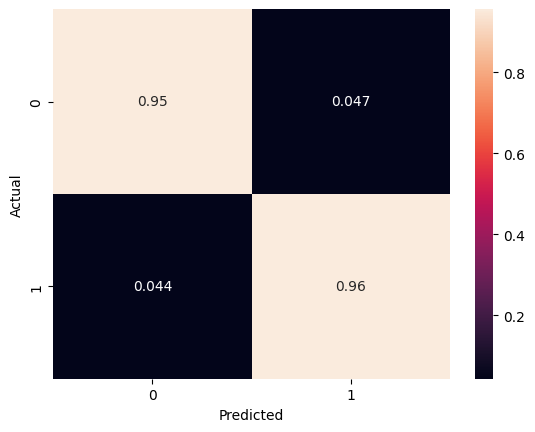

In [21]:
conf_matrix = confusion_matrix(y_test, predictions, normalize = "true")
sns.heatmap(conf_matrix, annot = True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#**ROC Curve**

Use the roc curve when you want to maximize the accuracy of one class while minimizing the loss in the accuracy of the other class. If the overall accuracy remains constant then it means that the accuracy of the other class is not compromised so much.

In our case we want to maximize the accuracy of the infected (negative) class, meaning that we want to maximize the True Negative Rate while losing minimum True Positives.

The reason is that it is much dangerous to declare people as healthy when they are infected then to declare them as infected when they are healthy.

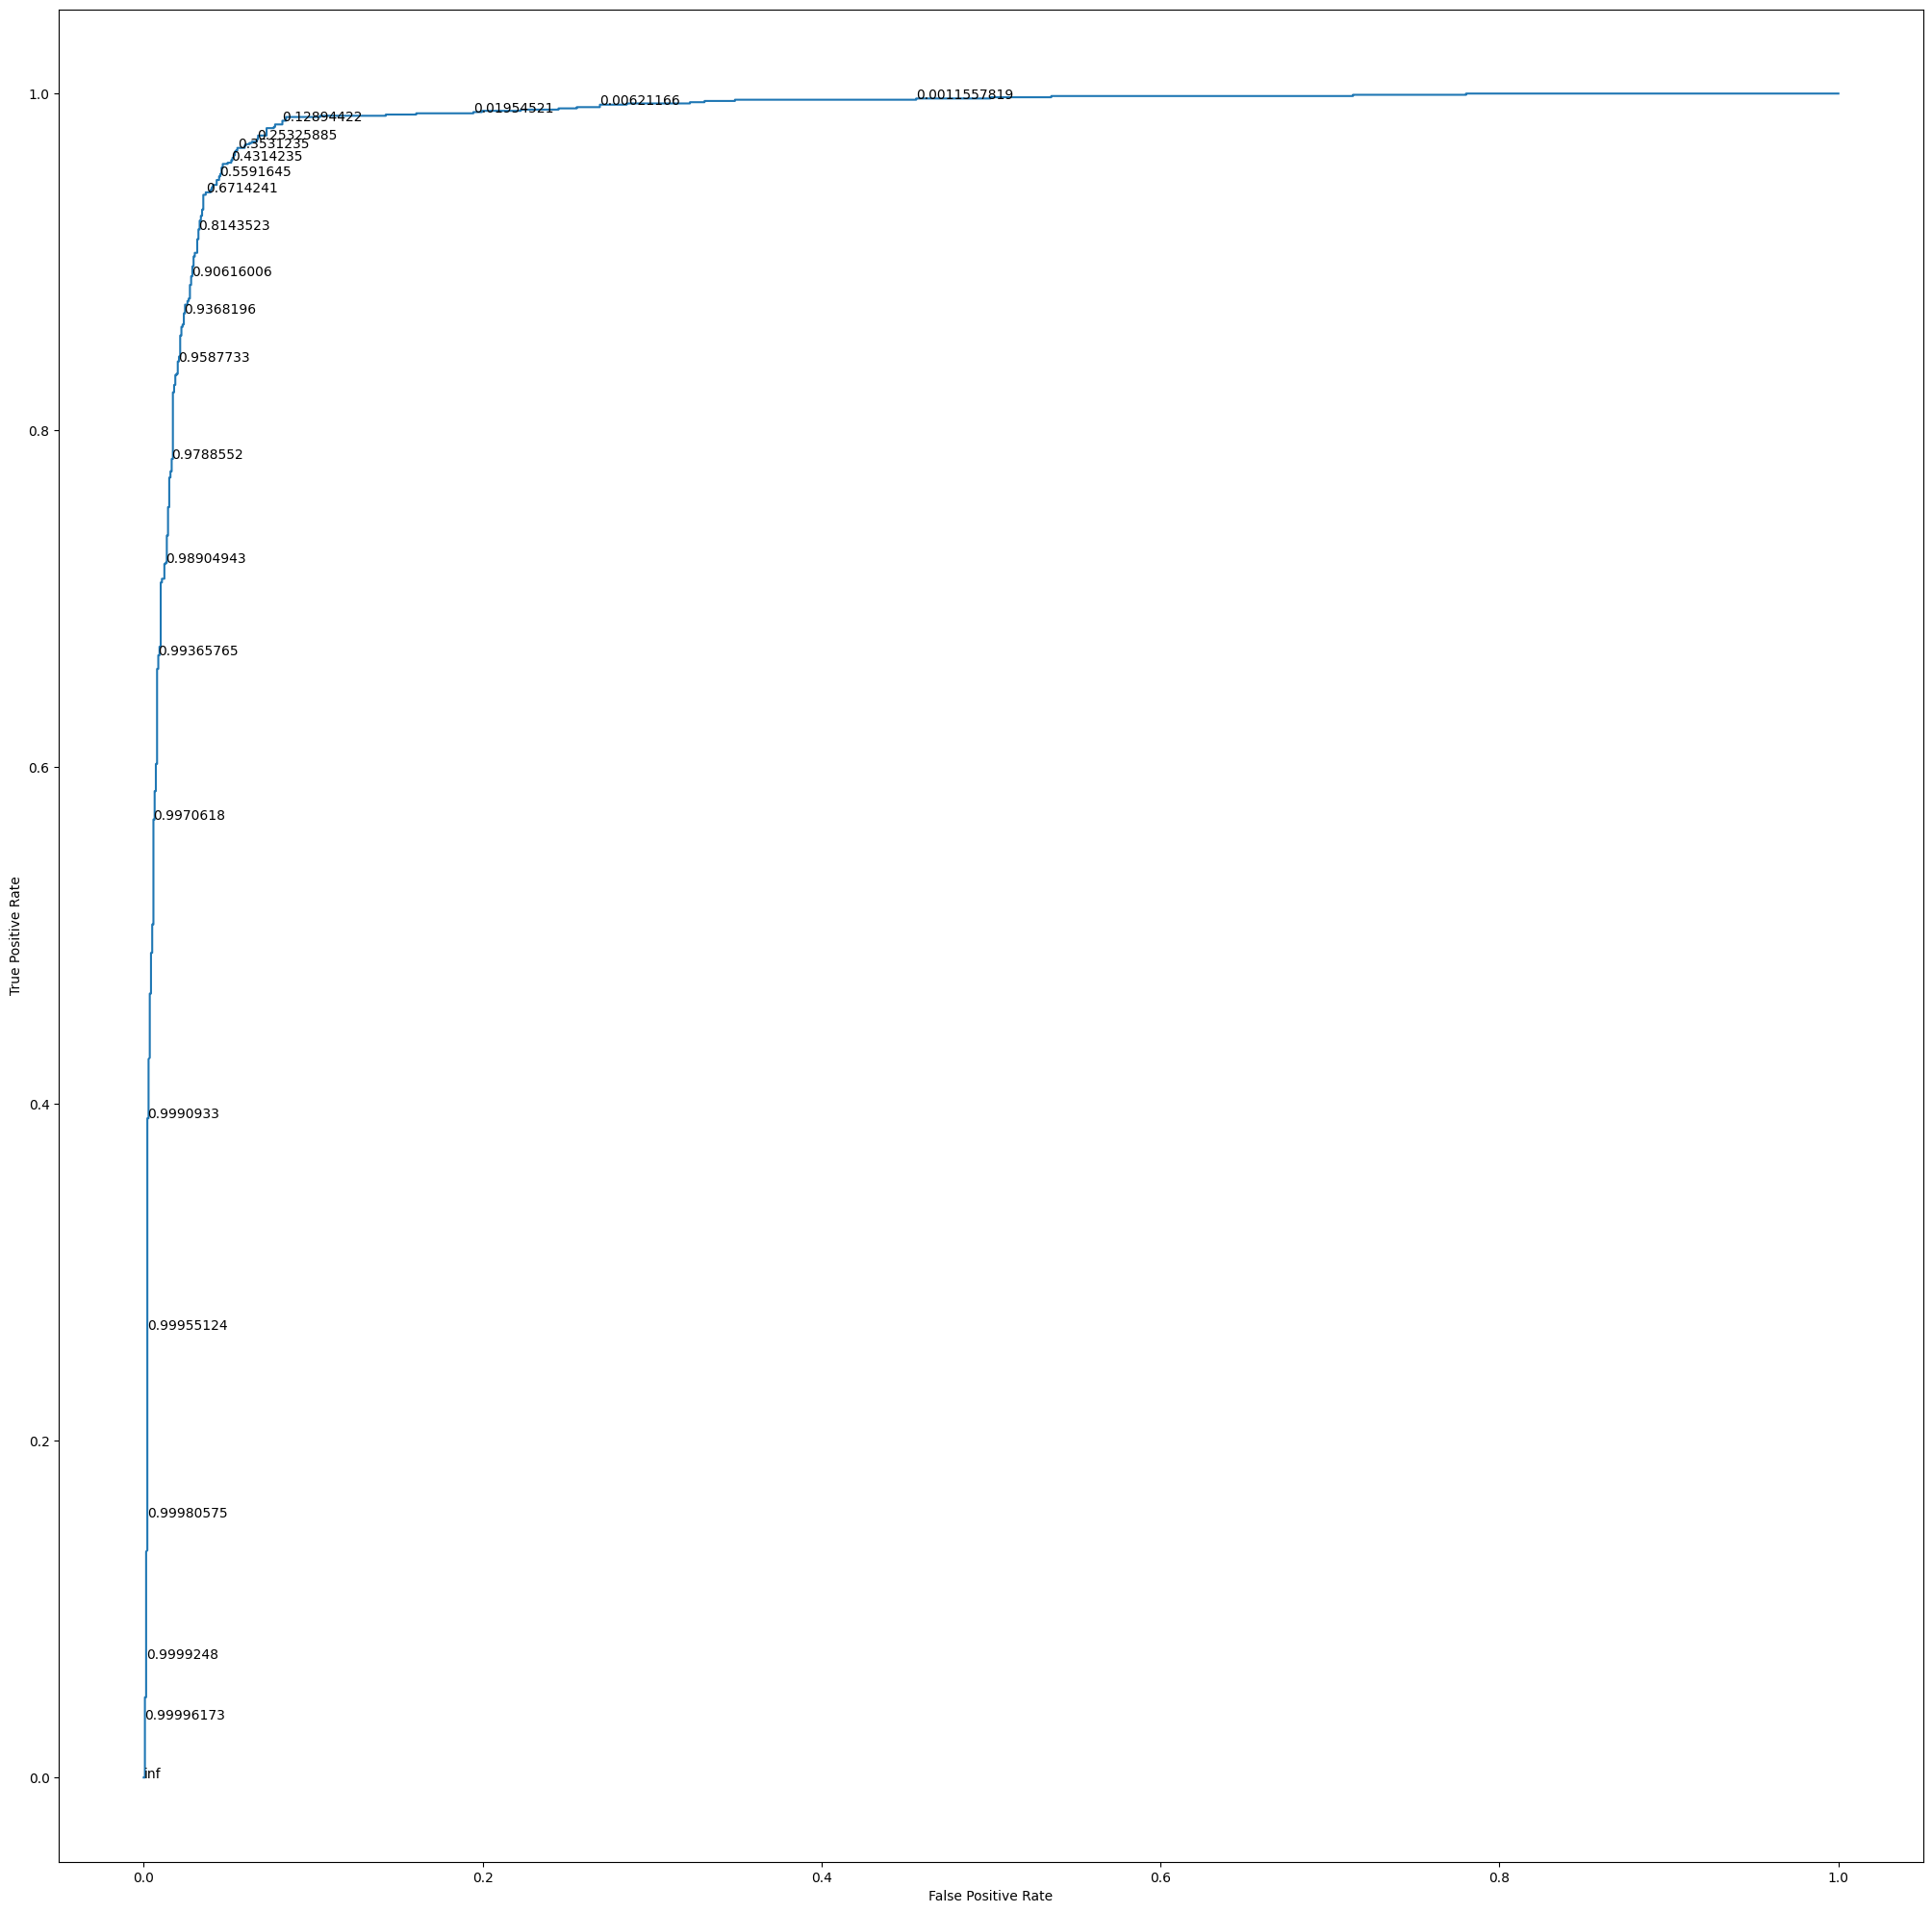

In [22]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
plt.figure(figsize=(25, 25))
plt.plot(fpr, tpr)
for i in range(0, len(thresholds), 10):
  plt.text(fpr[i], tpr[i], thresholds[i])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

From the plotted curve, observe the point 0.67. At this point there is a very minor decrease in true positive rate. So, we choose this as our threshold and plot the confusion matrix again.

In [23]:
predictions = (probabilities > 0.67).astype(int)
accuracy = accuracy_score(y_test, predictions) * 100
print(accuracy)

95.24845846935074


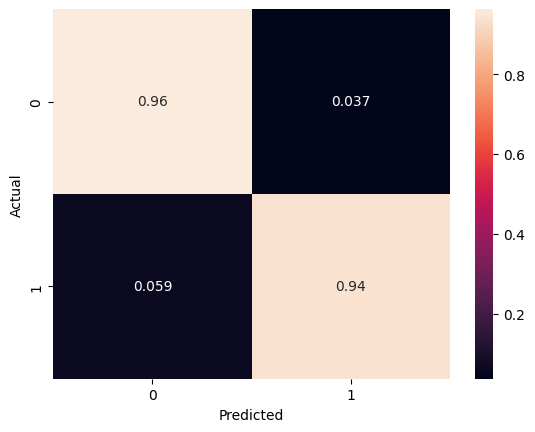

In [24]:
conf_matrix = confusion_matrix(y_test, predictions, normalize = "true")
sns.heatmap(conf_matrix, annot = True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##**Final Results**

Overall Accuracy: 94.9 %

True Positive Rate: 94 %

True Negative Rate: 96 %